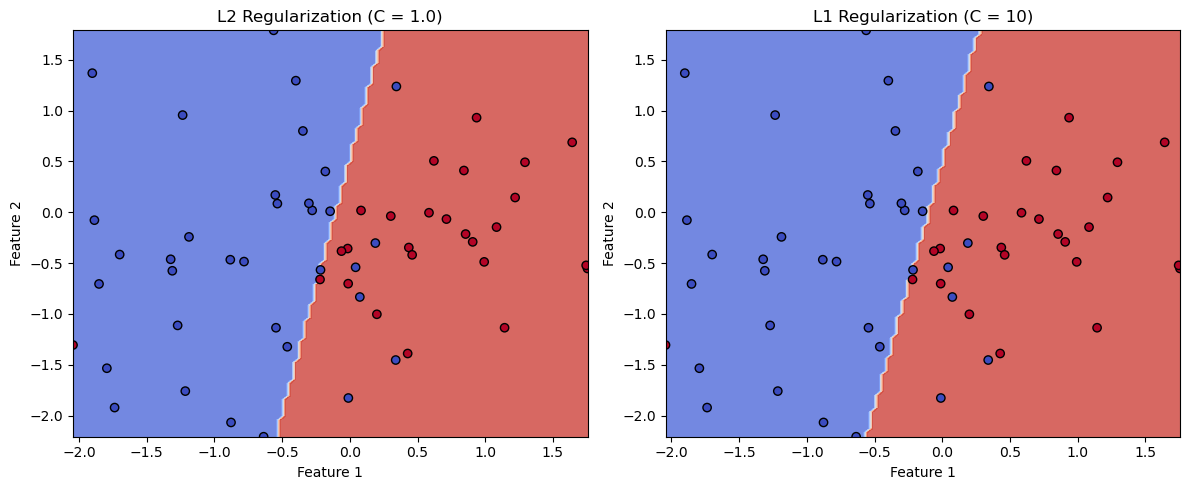

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Генерация данных
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Разделение на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание и обучение модели с L2 регуляризацией
C_l2 = 1.0  # Параметр регуляризации для L2
model_l2 = LogisticRegression(penalty='l2', C=C_l2)
model_l2.fit(X_train, y_train)

# Создание и обучение модели с L1 регуляризацией
C_l1 = 10  # Параметр регуляризации для L1
model_l1 = LogisticRegression(penalty='l1', C=C_l1, solver='saga')
model_l1.fit(X_train, y_train)

# Подготовка точек для графика
xx, yy = np.meshgrid(np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 100),
                     np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 100))

# Получение предсказаний для графика
Z_l2 = model_l2.predict(np.c_[xx.ravel(), yy.ravel()])
Z_l2 = Z_l2.reshape(xx.shape)

Z_l1 = model_l1.predict(np.c_[xx.ravel(), yy.ravel()])
Z_l1 = Z_l1.reshape(xx.shape)

# Визуализация разделения и разделяющей границы
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_l2, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='coolwarm')
plt.title(f'L2 Regularization (C = {C_l2})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_l1, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='coolwarm')
plt.title(f'L1 Regularization (C = {C_l1})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

313/313 [==============================] - 0s 698us/step


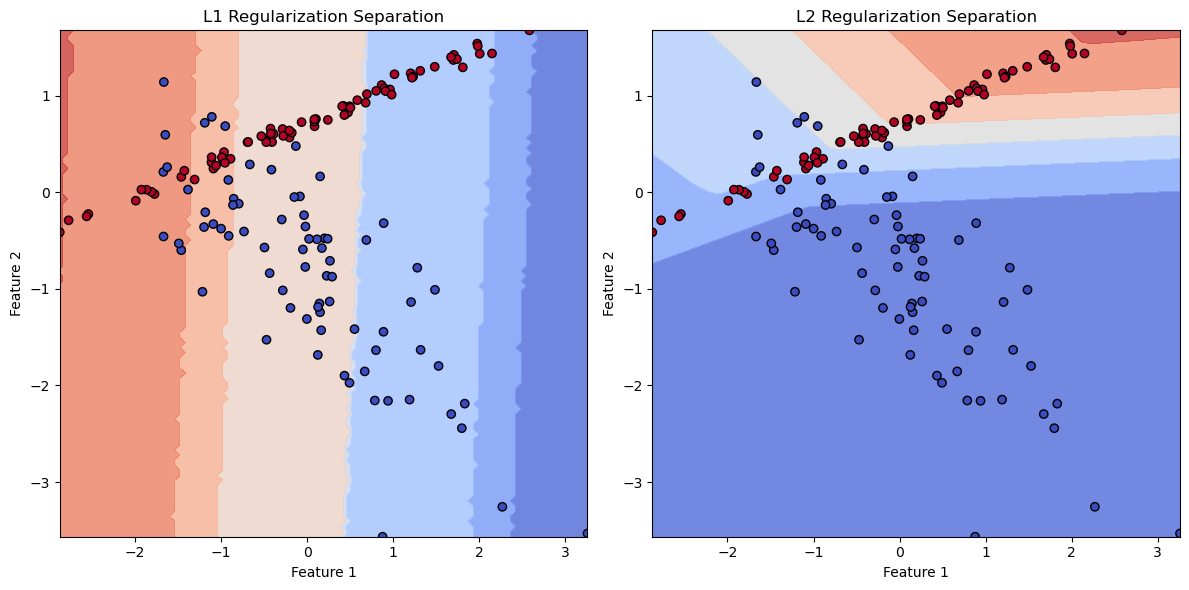

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Генерация данных
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Разделение на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание и обучение нейронной сети с L1 регуляризацией
model_l1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.1)),
    tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.1)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_l1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_l1.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

# Создание и обучение нейронной сети с L2 регуляризацией
model_l2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.1)),
    tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.1)),
    tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.1)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_l2.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

# Подготовка точек для графика
xx, yy = np.meshgrid(np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 100),
                     np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 100))
grid = np.c_[xx.ravel(), yy.ravel()]

# Получение предсказаний для графика
Z_l1 = model_l1.predict(grid)
Z_l1 = Z_l1.reshape(xx.shape)

Z_l2 = model_l2.predict(grid)
Z_l2 = Z_l2.reshape(xx.shape)

# Визуализация разделения и разделяющей границы для L1 регуляризации
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_l1, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='coolwarm')
plt.title('L1 Regularization Separation')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Визуализация разделения и разделяющей границы для L2 регуляризации
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_l2, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='coolwarm')
plt.title('L2 Regularization Separation')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

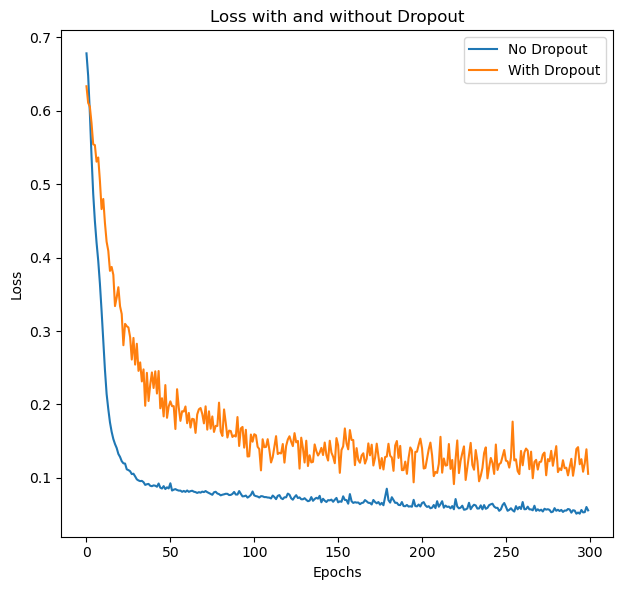

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Генерация данных
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Разделение на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание нейронной сети без Dropout
model_no_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_no_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Создание нейронной сети с Dropout
model_with_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_with_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Обучение нейронных сетей и запись истории лосса
history_no_dropout = model_no_dropout.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)
history_with_dropout = model_with_dropout.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)

# Визуализация графиков лосса
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history['loss'], label='No Dropout')
plt.plot(history_with_dropout.history['loss'], label='With Dropout')
plt.title('Loss with and without Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

<h1> Попробуем поставить dropout в разные места <h1>

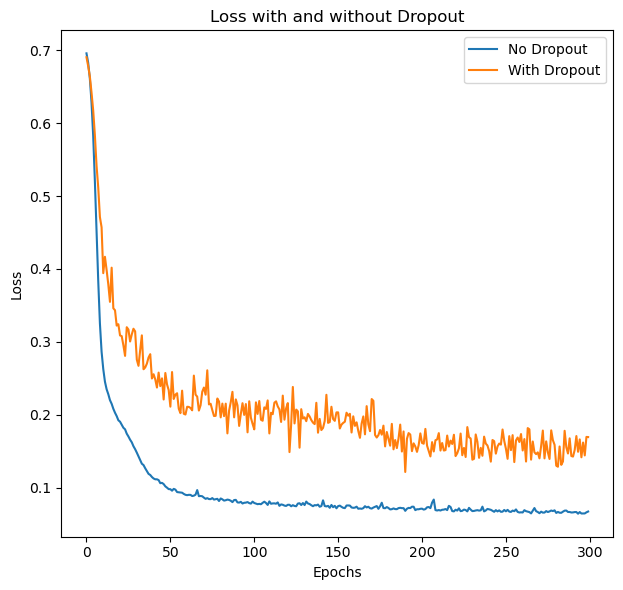

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Генерация данных
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Разделение на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание нейронной сети без Dropout
model_no_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_no_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Создание нейронной сети с Dropout
model_with_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_with_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Обучение нейронных сетей и запись истории лосса
history_no_dropout = model_no_dropout.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)
history_with_dropout = model_with_dropout.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)

# Визуализация графиков лосса
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history['loss'], label='No Dropout')
plt.plot(history_with_dropout.history['loss'], label='With Dropout')
plt.title('Loss with and without Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

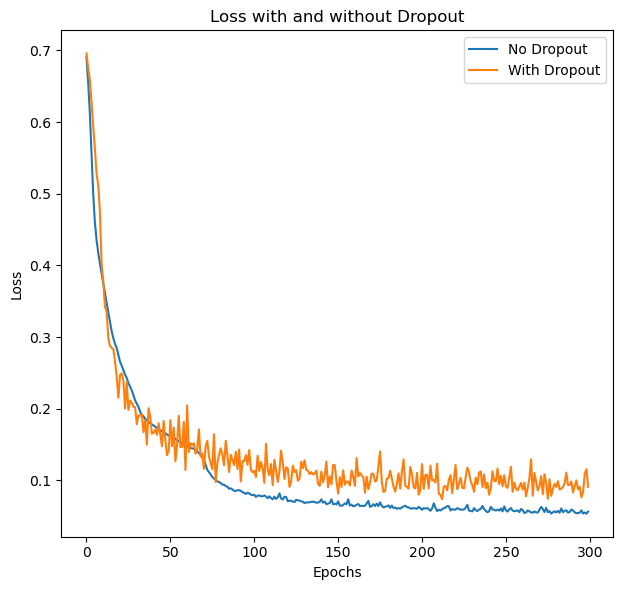

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Генерация данных
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Разделение на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание нейронной сети без Dropout
model_no_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_no_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Создание нейронной сети с Dropout
model_with_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_with_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Обучение нейронных сетей и запись истории лосса
history_no_dropout = model_no_dropout.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)
history_with_dropout = model_with_dropout.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)

# Визуализация графиков лосса
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history['loss'], label='No Dropout')
plt.plot(history_with_dropout.history['loss'], label='With Dropout')
plt.title('Loss with and without Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

<h1> Вывод: в этой задаче лучше ставить dropout в середине, хотя обычно лучше в конце <h1>

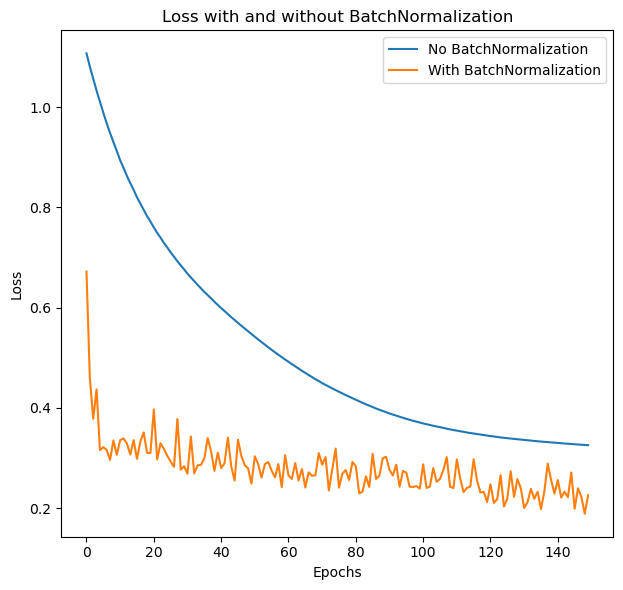

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Генерация данных
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Разделение на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание нейронной сети без BatchNormalization
model_no_bn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_no_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Создание нейронной сети с BatchNormalization
model_with_bn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_with_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Обучение нейронных сетей и запись истории лосса
history_no_bn = model_no_bn.fit(X_train, y_train, epochs=150, batch_size=16, verbose=0)
history_with_bn = model_with_bn.fit(X_train, y_train, epochs=150, batch_size=16, verbose=0)

# Визуализация графиков лосса
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_no_bn.history['loss'], label='No BatchNormalization')
plt.plot(history_with_bn.history['loss'], label='With BatchNormalization')
plt.title('Loss with and without BatchNormalization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

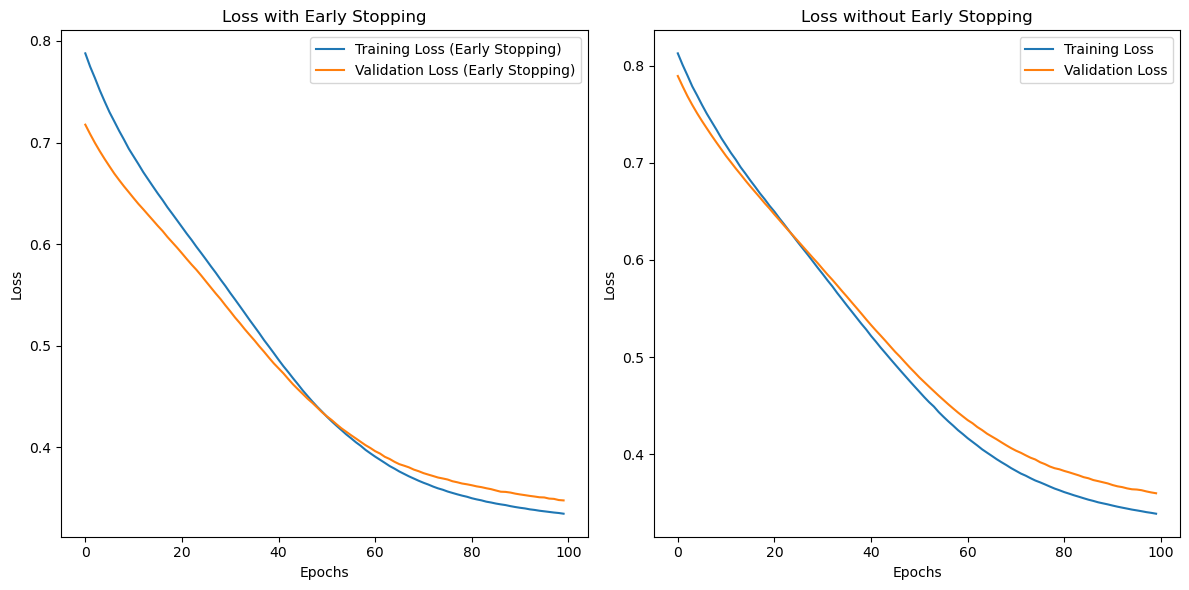

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

# Генерация данных
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Разделение на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание нейронной сети
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Создание callbacks для ранней остановки
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Создание двух одинаковых нейронных сетей с ранней остановкой
model1 = create_model()
history1 = model1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100,
                      batch_size=16, verbose=0, callbacks=[early_stopping])

model2 = create_model()
history2 = model2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100,
                      batch_size=16, verbose=0)

# Визуализация графиков лосса с ранней остановкой и без
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Training Loss (Early Stopping)')
plt.plot(history1.history['val_loss'], label='Validation Loss (Early Stopping)')
plt.title('Loss with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Loss without Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


170498071/170498071 [==============================] - 10s 0us/step


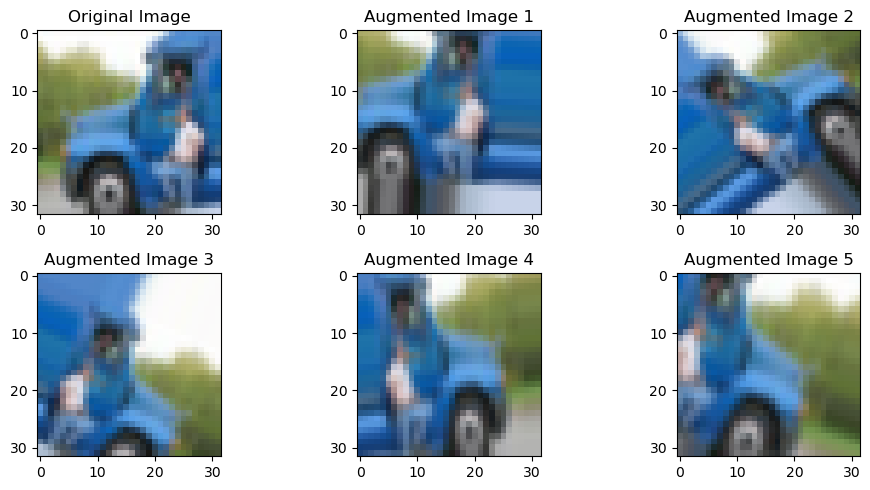

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import cifar10

# Загрузка данных CIFAR-10
(x_train, _), (_, _) = cifar10.load_data()

# Выбор случайного изображения для аугментации
image_index = np.random.randint(0, x_train.shape[0])
image = x_train[image_index]

# Создание генератора аугментации
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Преобразование и отображение аугментированных изображений
plt.figure(figsize=(10, 5))
plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title('Original Image')

# Генерация и отображение аугментированных изображений
for i, augmented_image in enumerate(datagen.flow(np.expand_dims(image, axis=0), batch_size=1)):
    if i >= 5:  # Отобразить 5 аугментированных изображений
        break
    plt.subplot(2, 3, i + 2)
    plt.imshow(augmented_image[0].astype('uint8'))
    plt.title(f'Augmented Image {i+1}')

plt.tight_layout()
plt.show()

<h1> Sequential API (последовательный API):
Этот подход используется в библиотеке Keras, входящей в состав TensorFlow. Sequential API позволяет создавать нейронные сети, в которых слои добавляются последовательно друг за другом. Это наиболее простой способ создания моделей с одним входом и одним выходом.<h1>

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Загрузка и предобработка данных CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Создание объекта ImageDataGenerator для аугментации данных
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.1
)

# Создание генераторов данных для обучения и валидации
batch_size = 32
train_generator = datagen.flow(x_train, y_train, batch_size=batch_size, subset='training')
validation_generator = datagen.flow(x_train, y_train, batch_size=batch_size, subset='validation')

# Создание модели с помощью Sequential API
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Компиляция модели
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Обучение модели с использованием генераторов данных
history = model.fit(train_generator,
                    epochs=10,
                    validation_data=validation_generator)

# Оценка модели на тестовых данных
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy:", test_accuracy)


Epoch 1/10
1407/1407 [==============================] - 34s 24ms/step - loss: 1.7519 - accuracy: 0.0990 - val_loss: 1.4896 - val_accuracy: 0.0670
Epoch 2/10
1407/1407 [==============================] - 33s 24ms/step - loss: 1.4501 - accuracy: 0.0936 - val_loss: 1.3651 - val_accuracy: 0.0614
Epoch 3/10
1407/1407 [==============================] - 33s 23ms/step - loss: 1.3236 - accuracy: 0.0943 - val_loss: 1.3076 - val_accuracy: 0.0854
Epoch 4/10
1407/1407 [==============================] - 34s 24ms/step - loss: 1.2382 - accuracy: 0.0942 - val_loss: 1.1921 - val_accuracy: 0.0950
Epoch 5/10
1407/1407 [==============================] - 33s 23ms/step - loss: 1.1876 - accuracy: 0.0980 - val_loss: 1.1492 - val_accuracy: 0.1138
Epoch 6/10
1407/1407 [==============================] - 32s 23ms/step - loss: 1.1314 - accuracy: 0.0983 - val_loss: 1.1284 - val_accuracy: 0.1052
Epoch 7/10
1407/1407 [==============================] - 32s 23ms/step - loss: 1.0883 - accuracy: 0.0987 - val_loss: 1.0340 -

<h1> Functional API (функциональный API):
Также предоставляемый библиотекой Keras, функциональный API позволяет создавать более сложные и гибкие модели. В отличие от последовательного API, здесь можно создавать модели с несколькими входами и/или выходами, а также делать более сложные манипуляции с данными между слоями.<h1>

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

# Загрузка и предобработка данных CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Создание объекта ImageDataGenerator для аугментации данных
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.1
)

# Создание генераторов данных для обучения и валидации
batch_size = 32
train_generator = datagen.flow(x_train, y_train, batch_size=batch_size, subset='training')
validation_generator = datagen.flow(x_train, y_train, batch_size=batch_size, subset='validation')

# Создание входного слоя для функциональной модели
input_layer = Input(shape=(32, 32, 3))

# Определение архитектуры модели с использованием функционального API
x = Conv2D(32, (3, 3), activation='relu')(input_layer)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output_layer = Dense(10, activation='softmax')(x)

# Создание функциональной модели
model = Model(inputs=input_layer, outputs=output_layer)

# Компиляция модели
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Обучение модели с использованием генераторов данных
history = model.fit(train_generator,
                    epochs=10,
                    validation_data=validation_generator)

# Оценка модели на тестовых данных
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy:", test_accuracy)

Epoch 1/10
1407/1407 [==============================] - 33s 23ms/step - loss: 1.7941 - accuracy: 0.1100 - val_loss: 1.5609 - val_accuracy: 0.1238
Epoch 2/10
1407/1407 [==============================] - 32s 23ms/step - loss: 1.4893 - accuracy: 0.0928 - val_loss: 1.4143 - val_accuracy: 0.1004
Epoch 3/10
1407/1407 [==============================] - 33s 23ms/step - loss: 1.3665 - accuracy: 0.0951 - val_loss: 1.3083 - val_accuracy: 0.1390
Epoch 4/10
1407/1407 [==============================] - 32s 23ms/step - loss: 1.2837 - accuracy: 0.0952 - val_loss: 1.2755 - val_accuracy: 0.1052
Epoch 5/10
1407/1407 [==============================] - 32s 23ms/step - loss: 1.2354 - accuracy: 0.0961 - val_loss: 1.1796 - val_accuracy: 0.0800
Epoch 6/10
1407/1407 [==============================] - 33s 23ms/step - loss: 1.1881 - accuracy: 0.0953 - val_loss: 1.1999 - val_accuracy: 0.1378
Epoch 7/10
1407/1407 [==============================] - 32s 23ms/step - loss: 1.1579 - accuracy: 0.0978 - val_loss: 1.1037 -

<h1> PyTorch <h1>

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Определение класса модели
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(in_features=16 * 16 * 16, out_features=10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(-1, 16 * 16 * 16)
        x = self.fc(x)
        return x

# Загрузка и предобработка данных CIFAR-10
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True)

# Создание экземпляра модели
net = SimpleCNN()

# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# Обучение модели
for epoch in range(5):  # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

OSError: [WinError 182] Операционная система не может запустить %1. Error loading "C:\Users\vboro\.conda\envs\py310\lib\site-packages\torch\lib\fbgemm.dll" or one of its dependencies.

<h1> Возможное решение - импортить торч перед керасом <h1>